# 03 — Supervised Prediction Module

**Goal:** Train a LightGBM regressor to predict `ProtocolValue(t+1)` given the current state vector.

**This notebook:**
1. Loads the feature matrix from notebook 02
2. Trains LightGBM with walk-forward cross-validation (respects temporal order)
3. Compares against baselines (LastValue, RollingMean, SessionMean)
4. Evaluates directional accuracy (does the model get the direction right?)
5. Saves the trained model

**Design choice:** Walk-forward CV — train on subsessions 1..k, test on k+1. This simulates real-time deployment and avoids data leakage.

In [5]:
import sys, json, warnings, pickle
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
OUTPUTS_DIR   = Path('../outputs')
FIGURES_DIR   = Path('../outputs/figures')

meta         = json.loads((PROCESSED_DIR/'feature_meta.json').read_text())
TARGET       = meta['target']
TARGET_NEXT  = meta['target_next']
FEATURE_COLS = meta['feature_cols']
SS_COL       = 'subsession'

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.labelcolor':'#e6edf3','xtick.color':'#8b949e',
    'ytick.color':'#8b949e','text.color':'#e6edf3',
    'grid.color':'#21262d','grid.linestyle':'--','font.family':'monospace'
})
print('Setup complete. Features:', len(FEATURE_COLS))

Setup complete. Features: 246


## 1. Load Feature Matrix

In [6]:
df = pd.read_parquet(PROCESSED_DIR/'features.parquet')
# Use game sessions only for prediction modelling
df_game = df[df[SS_COL] > 0].copy()
df_game = df_game.dropna(subset=FEATURE_COLS + [TARGET_NEXT])
print(f'Game sessions: {df_game.shape[0]:,} rows after dropping NaN')
print(f'SubSessions available: {sorted(df_game[SS_COL].unique())}')

Game sessions: 2,658 rows after dropping NaN
SubSessions available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


## 2. Walk-Forward Cross-Validation

In [7]:
game_ss = sorted(df_game[SS_COL].unique())
# Need at least 2 subsessions to train+test
# Walk-forward: train on [1..k], test on [k+1]

LGBM_PARAMS = {
    'objective':        'regression',
    'metric':           'mae',
    'n_estimators':     300,
    'learning_rate':    0.05,
    'num_leaves':       31,
    'min_child_samples':10,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'random_state':     42,
    'verbose':         -1,
}

fold_results = []

for test_ss in game_ss[1:]:  # start from ss2 (need ss1 for training)
    train_ss_list = [s for s in game_ss if s < test_ss]
    train_df = df_game[df_game[SS_COL].isin(train_ss_list)]
    test_df  = df_game[df_game[SS_COL] == test_ss]

    if len(train_df) < 10 or len(test_df) < 5:
        continue

    X_train = train_df[FEATURE_COLS].values
    y_train = train_df[TARGET_NEXT].values
    X_test  = test_df[FEATURE_COLS].values
    y_test  = test_df[TARGET_NEXT].values

    model = lgb.LGBMRegressor(**LGBM_PARAMS)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(-1)])

    y_pred  = model.predict(X_test)
    mae     = mean_absolute_error(y_test, y_pred)
    rmse    = mean_squared_error(y_test, y_pred)**0.5
    r2      = r2_score(y_test, y_pred)
    # Directional accuracy
    y_curr  = test_df[TARGET].values
    dir_acc = np.mean(np.sign(y_pred - y_curr) == np.sign(y_test - y_curr))

    fold_results.append({
        'test_ss': test_ss, 'train_n': len(train_df), 'test_n': len(test_df),
        'MAE': mae, 'RMSE': rmse, 'R2': r2, 'DirectionalAcc': dir_acc,
        'y_test': y_test, 'y_pred': y_pred,
    })
    print(f'  Fold ss{test_ss}: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}  DirAcc={dir_acc:.3f}')

metrics_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ('y_test','y_pred')}
                            for r in fold_results])
print('\nWalk-forward CV summary:')
print(metrics_df.set_index('test_ss').round(4).to_string())
print(f'\nMean MAE:  {metrics_df["MAE"].mean():.4f} ± {metrics_df["MAE"].std():.4f}')
print(f'Mean R2:   {metrics_df["R2"].mean():.4f}')
print(f'Mean DirAcc: {metrics_df["DirectionalAcc"].mean():.3f}')

  Fold ss2: MAE=0.4034  RMSE=0.5280  R2=0.0024  DirAcc=0.670
  Fold ss3: MAE=0.3664  RMSE=0.4771  R2=0.0061  DirAcc=0.682
  Fold ss4: MAE=0.3169  RMSE=0.4203  R2=-0.0060  DirAcc=0.675
  Fold ss5: MAE=0.3449  RMSE=0.4640  R2=-0.0012  DirAcc=0.684
  Fold ss6: MAE=0.3558  RMSE=0.4908  R2=0.0523  DirAcc=0.711
  Fold ss7: MAE=0.3276  RMSE=0.4571  R2=-0.0407  DirAcc=0.667
  Fold ss8: MAE=0.3175  RMSE=0.4226  R2=0.0299  DirAcc=0.639
  Fold ss9: MAE=0.3739  RMSE=0.4912  R2=-0.0200  DirAcc=0.678

Walk-forward CV summary:
         train_n  test_n     MAE    RMSE      R2  DirectionalAcc
test_ss                                                         
2            234     412  0.4034  0.5280  0.0024          0.6699
3            646     264  0.3664  0.4771  0.0061          0.6818
4            910     311  0.3169  0.4203 -0.0060          0.6752
5           1221     335  0.3449  0.4640 -0.0012          0.6836
6           1556     308  0.3558  0.4908  0.0523          0.7110
7           1864     264  0

## 3. Baseline Comparison

In [8]:
# ── Inline baseline evaluation (avoids recomputing shift(-1) on filtered df) ─
# y_true comes from df_game[TARGET_NEXT] which was already computed correctly
# in notebook 02 and survived the dropna() filter.

y_true = df_game[TARGET_NEXT].values

def _eval(name, y_pred_arr):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred_arr))
    yt, yp = y_true[mask], y_pred_arr[mask]
    return {
        'MAE':  mean_absolute_error(yt, yp),
        'RMSE': mean_squared_error(yt, yp) ** 0.5,
        'R2':   r2_score(yt, yp),
        'n':    int(mask.sum()),
    }

# 1. LastValue — predict next = current
lv_metrics = _eval('LastValue', df_game[TARGET].values)

# 2. RollingMean(10) — within-subsession rolling mean of last 10 samples
rm10_pred = (
    df_game.groupby(SS_COL)[TARGET]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
    .values
)
rm10_metrics = _eval('RollingMean(w=10)', rm10_pred)

# 3. SessionMean — mean of subsession 0 broadcast to all rows
#    Load the full feature matrix so ss=0 is available.
df_full = pd.read_parquet(PROCESSED_DIR / 'features.parquet')
session_mean = df_full[df_full[SS_COL] == 0][TARGET].mean()
sm_pred = np.full(len(df_game), session_mean)
sm_metrics = _eval('SessionMean(baseline)', sm_pred)

baseline_results = pd.DataFrame(
    [lv_metrics, rm10_metrics, sm_metrics],
    index=['LastValue', 'RollingMean(w=10)', 'SessionMean(baseline)'],
)
print(f'Baseline means (session_mean={session_mean:.4f})')
print(baseline_results.round(4).to_string())

# 4. Add LightGBM walk-forward mean
lgbm_row = pd.DataFrame([{
    'MAE':  metrics_df['MAE'].mean(),
    'RMSE': metrics_df['RMSE'].mean(),
    'R2':   metrics_df['R2'].mean(),
    'n':    df_game.shape[0],
}], index=['LightGBM (walk-forward mean)'])

comparison = pd.concat([baseline_results, lgbm_row]).sort_values('MAE')
print('Full comparison (sorted by MAE — lower is better):')
print(comparison.round(4).to_string())

Baseline means (session_mean=-0.1914)
                          MAE    RMSE      R2     n
LastValue              0.4786  0.6198 -0.6703  2658
RollingMean(w=10)      0.3726  0.4693  0.0429  2649
SessionMean(baseline)  0.3943  0.5026 -0.0983  2658
Full comparison (sorted by MAE — lower is better):
                                 MAE    RMSE      R2     n
LightGBM (walk-forward mean)  0.3508  0.4689  0.0029  2658
RollingMean(w=10)             0.3726  0.4693  0.0429  2649
SessionMean(baseline)         0.3943  0.5026 -0.0983  2658
LastValue                     0.4786  0.6198 -0.6703  2658


## 4. Train Final Model on All Game Sessions

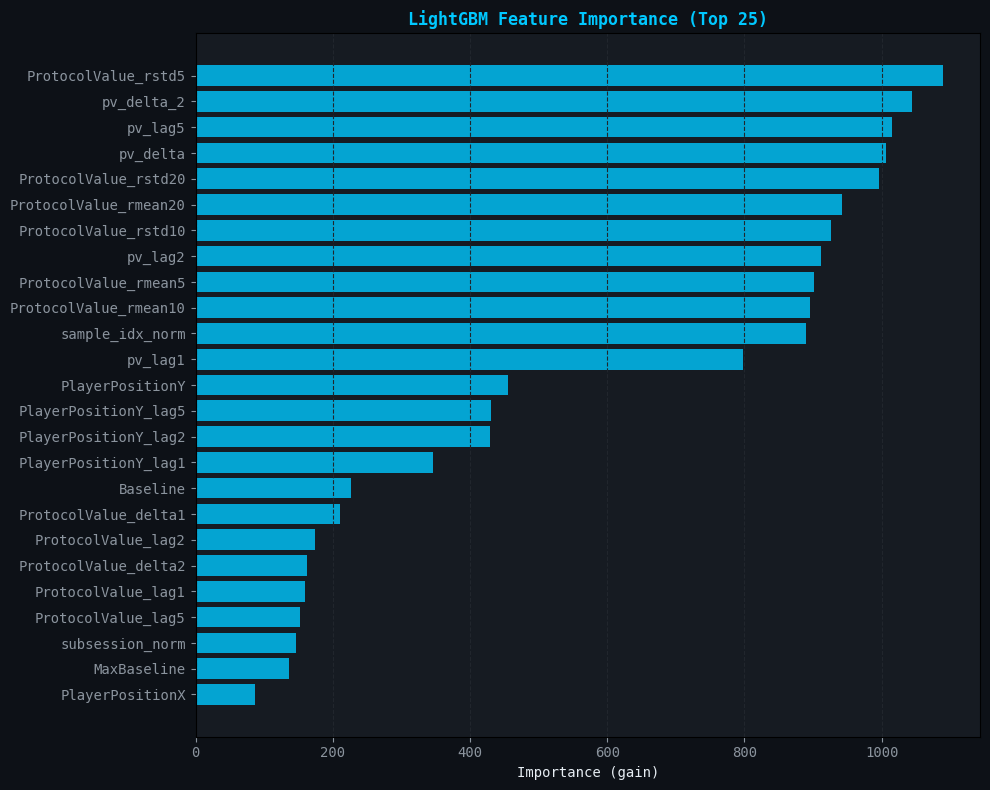

Top 15 features:
              feature  importance
  ProtocolValue_rstd5        1089
           pv_delta_2        1045
              pv_lag5        1015
             pv_delta        1007
 ProtocolValue_rstd20         996
ProtocolValue_rmean20         942
 ProtocolValue_rstd10         926
              pv_lag2         912
 ProtocolValue_rmean5         901
ProtocolValue_rmean10         896
      sample_idx_norm         890
              pv_lag1         798
      PlayerPositionY         456
 PlayerPositionY_lag5         430
 PlayerPositionY_lag2         429


In [9]:
X_all = df_game[FEATURE_COLS].values
y_all = df_game[TARGET_NEXT].values

final_model = lgb.LGBMRegressor(**{**LGBM_PARAMS, 'n_estimators': 500})
final_model.fit(X_all, y_all, callbacks=[lgb.log_evaluation(-1)])

# Feature importance
importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': final_model.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top25 = importance_df.head(25)
ax.barh(top25['feature'][::-1], top25['importance'][::-1], color='#00c8ff', alpha=0.8)
ax.set_title('LightGBM Feature Importance (Top 25)', color='#00c8ff', fontweight='bold')
ax.set_xlabel('Importance (gain)')
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('../outputs/figures/lgbm_feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('Top 15 features:')
print(importance_df.head(15).to_string(index=False))

## 5. Prediction vs. True — Visual Check

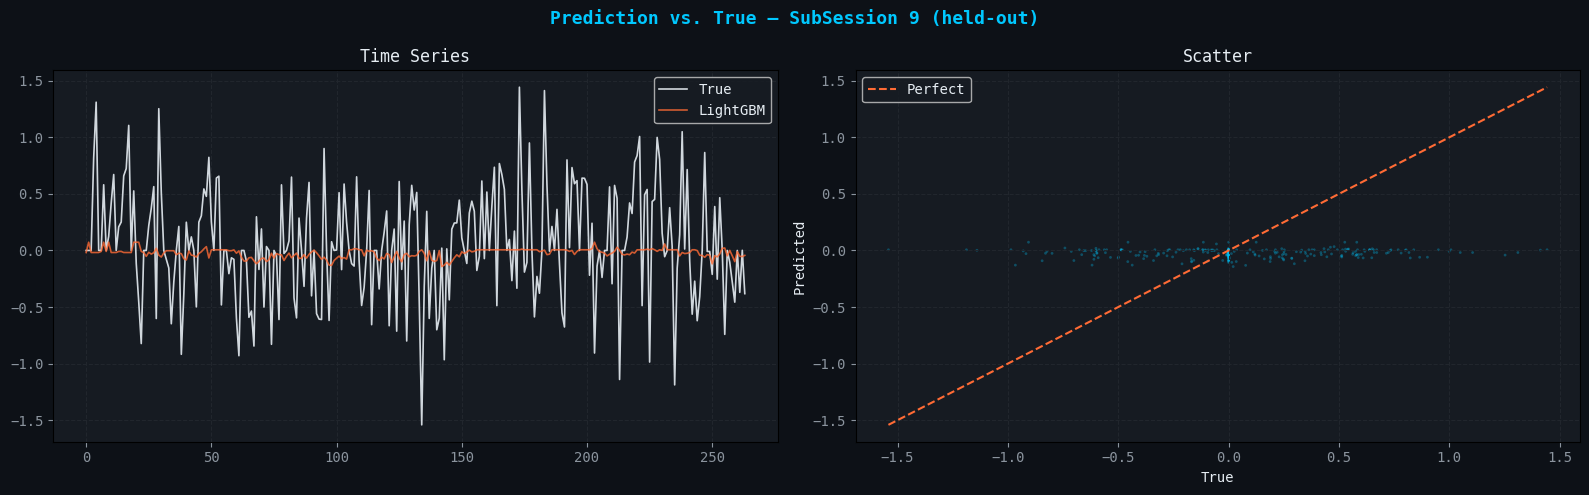

In [10]:
# Use last fold for visual inspection
last_fold = fold_results[-1]
y_test = last_fold['y_test']
y_pred = last_fold['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Prediction vs. True — SubSession {last_fold["test_ss"]} (held-out)',
             color='#00c8ff', fontsize=13, fontweight='bold')

n = len(y_test)
axes[0].plot(y_test, color='#e6edf3', lw=1.2, label='True', alpha=0.9)
axes[0].plot(y_pred, color='#ff6b35', lw=1.2, label='LightGBM', alpha=0.8)
axes[0].set_title('Time Series')
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(y_test, y_pred, alpha=0.3, s=4, color='#00c8ff', edgecolors='none')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color='#ff6b35', lw=1.5, linestyle='--', label='Perfect')
axes[1].set_xlabel('True')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Scatter')
axes[1].legend()
axes[1].grid(True)

for ax in axes: ax.set_facecolor('#161b22')
plt.tight_layout()
plt.savefig('../outputs/figures/prediction_vs_true.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 6. Save Model

In [11]:
model_path = OUTPUTS_DIR / 'lgbm_predictor.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({'model': final_model, 'feature_cols': FEATURE_COLS,
                 'cv_metrics': metrics_df.to_dict()}, f)
print(f'Model saved: {model_path}')
print(f'CV MAE: {metrics_df["MAE"].mean():.4f} ± {metrics_df["MAE"].std():.4f}')
print(f'CV DirAcc: {metrics_df["DirectionalAcc"].mean():.3f}')

Model saved: ../outputs/lgbm_predictor.pkl
CV MAE: 0.3508 ± 0.0303
CV DirAcc: 0.676
